In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [2]:
# -------------------- LOAD DATA --------------------
df = pd.read_csv("manufacturing.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype 

In [4]:
X = df.drop("Quality Rating", axis=1)
y = df["Quality Rating"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("LINEAR MODEL")
print("R2:", r2_score(y_test, y_pred_linear))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred_linear)))

LINEAR MODEL
R2: 0.5145614193832739
RMSE: 9.955027924590269


In [7]:
degrees = [2, 3]

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nPOLYNOMIAL DEGREE {d}")
    print("R2:", r2_score(y_test, y_pred))
    print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))


POLYNOMIAL DEGREE 2
R2: 0.9263893126590478
RMSE: 3.876553432531214

POLYNOMIAL DEGREE 3
R2: 0.9970821289345488
RMSE: 0.771806419817827


In [8]:
best_degree = 2

final_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("\nFINAL MODEL")
print("R2:", r2_score(y_test, y_pred_final))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred_final)))


FINAL MODEL
R2: 0.9263893126590478
RMSE: 3.876553432531214


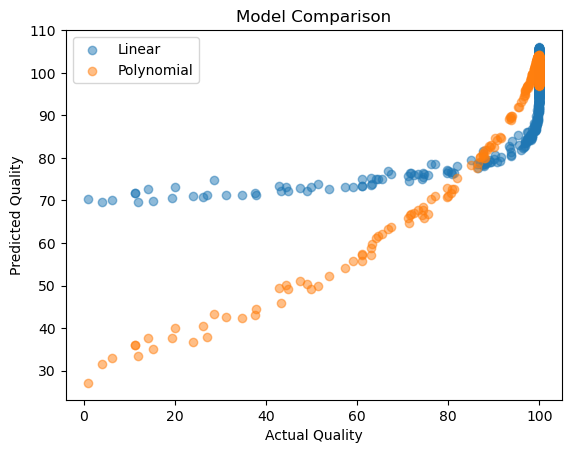

In [9]:
plt.scatter(y_test, y_pred_linear, label="Linear", alpha=0.5)
plt.scatter(y_test, y_pred_final, label="Polynomial", alpha=0.5)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [10]:
sample = pd.DataFrame([{
    "Temperature (°C)": 200,
    "Pressure (kPa)": 10,
    "Temperature x Pressure": 2000,
    "Material Fusion Metric": 50000,
    "Material Transformation Metric": 9000000
}])

prediction = final_model.predict(sample)

print("Predicted Quality Rating:", prediction[0])

Predicted Quality Rating: -1414.9532197556512
